In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

## DOPASUJMY KRZYWĄ KAPLANA-MEIERA

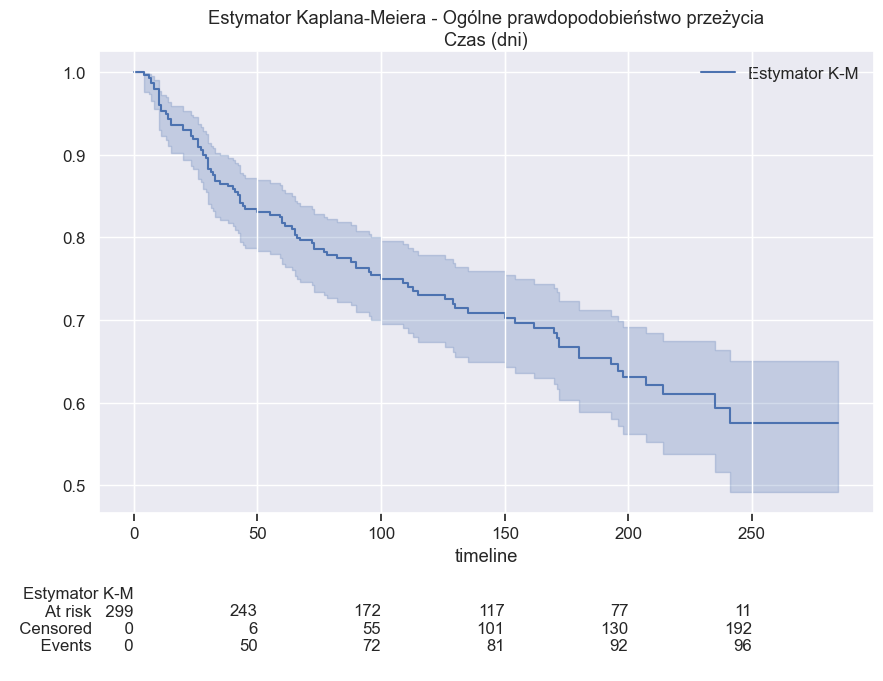

In [10]:
## Krzywa Kaplana-Meiera z przedziałami ufności i tabelą osób narażonych na ryzyko

kmf = KaplanMeierFitter()
kmf.fit(durations=df['time'], event_observed=df['DEATH_EVENT'], label='Estymator K-M', alpha=0.05)

plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
kmf.plot_survival_function()
add_at_risk_counts(kmf, ax=ax)
plt.title('Estymator Kaplana-Meiera - Ogólne prawdopodobieństwo przeżycia')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True)
plt.show()

In [25]:
full_km_report = kmf.survival_function_.join(kmf.event_table).join(kmf.confidence_interval_).drop(columns=['entrance', 'removed'])
full_km_report = full_km_report.rename(columns={
    'Estymator K-M': 'przeżycie',
    'observed': 'zdarzenia',
    'censored': 'censorowane',
    'at_risk': 'narażeni na ryzyko',
    'Estymator K-M_lower_0.95': 'dolny przedz. ufności',
    'Estymator K-M_upper_0.95': 'górny przedz. ufności'
})
full_km_report['Skumulowana funkcja hazardu'] = -(np.log(full_km_report['przeżycie']))
full_km_report['Skumulowana funkcja hazardu'][0] = 0
display(full_km_report)
# display(full_km_report[full_km_report['zdarzenia']>0])

C:\Users\matma\AppData\Local\Temp\ipykernel_2020\3622096065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_km_report['Skumulowana funkcja hazardu'][0] = 0


,przeżycie,zdarzenia,censorowane,narażeni na ryzyko,dolny przedz. ufności,górny przedz. ufności,Skumulowana funkcja hazardu
timeline,,,,,,,
0.0,1.000000,0,0,299,1.000000,1.000000,0.000000
4.0,0.996656,1,0,299,0.976498,0.999528,0.003350
6.0,0.993311,1,0,298,0.973522,0.998323,0.006711
7.0,0.986622,2,0,297,0.964751,0.994958,0.013468
8.0,0.979933,2,0,295,0.955881,0.990935,0.020271
...,...,...,...,...,...,...,...
270.0,0.575705,0,2,6,0.491856,0.650723,0.552160
271.0,0.575705,0,1,4,0.491856,0.650723,0.552160
278.0,0.575705,0,1,3,0.491856,0.650723,0.552160


## PORÓWNANIA KRZYWYCH K-M

In [41]:


def analiza_nieparametryczna_grup(df, group_col, labels_dict, title):
    """
    Funkcja wykonuje kompleksową analizę nieparametryczną:
    - Wykresy KM dla wszystkich grup
    - Testy globalne (Log-rank, Wilcoxon)
    - Porównania parami (jeśli grupy > 2)
    """
    plt.figure(figsize=(10, 7))
    ax = plt.subplot(111)
    
    unique_groups = sorted(df[group_col].unique())
    group_data = {}
    
    # 1. Rysowanie krzywych
    for val in unique_groups:
        mask = (df[group_col] == val)
        label = labels_dict.get(val, f'Grupa {val}')
        
        kmf = KaplanMeierFitter()
        kmf.fit(df['time'][mask], df['DEATH_EVENT'][mask], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Zapisujemy dane do testów parami
        group_data[val] = {
            'time': df['time'][mask],
            'event': df['DEATH_EVENT'][mask],
            'label': label
        }
    
    # 2. Testy Globalne
    res_lr = multivariate_logrank_test(df['time'], df[group_col], df['DEATH_EVENT'])
    res_wil = multivariate_logrank_test(df['time'], df[group_col], df['DEATH_EVENT'], weightings="wilcoxon")
    
    txt_lr = f"Test Log-rank: p-value = {res_lr.p_value:.4f}"
    txt_wil = f"Test Wilcoxon: p-value = {res_wil.p_value:.4f}"
    
    # 3. Formatowanie wykresu
    plt.title(f'Krzywe przeżycia K-M: {title}', fontsize=14, pad=20)
    plt.xlabel('Czas (dni)')
    plt.ylabel('Prawdopodobieństwo przeżycia S(t)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.text(0.05, 0.1, f"{txt_lr}\n{txt_wil}", transform=ax.transAxes, fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))
    plt.tight_layout()
    plt.show()

    # 4. Wydruk wyników i Porównania Parami (analogicznie do prowadzącej)
    print(f"\n--- WYNIKI DLA ZMIENNEJ: {title} ---")
    print(txt_lr)
    print(txt_wil)
    
    if len(unique_groups) > 2:
        print("\nPorównania parami (Log-rank):")
        pair_results = []
        for i, g1 in enumerate(unique_groups[:-1]):
            for g2 in unique_groups[i+1:]:
                test = logrank_test(group_data[g1]['time'], group_data[g2]['time'], 
                                    group_data[g1]['event'], group_data[g2]['event'])
                pair_results.append({
                    'Grupa A': group_data[g1]['label'],
                    'Grupa B': group_data[g2]['label'],
                    'p-value': test.p_value
                })
        df_pairs = pd.DataFrame(pair_results).sort_values(by='p-value')
        display(df_pairs.style.format({'p-value': '{:.6f}'}))
    print("-" * 60)



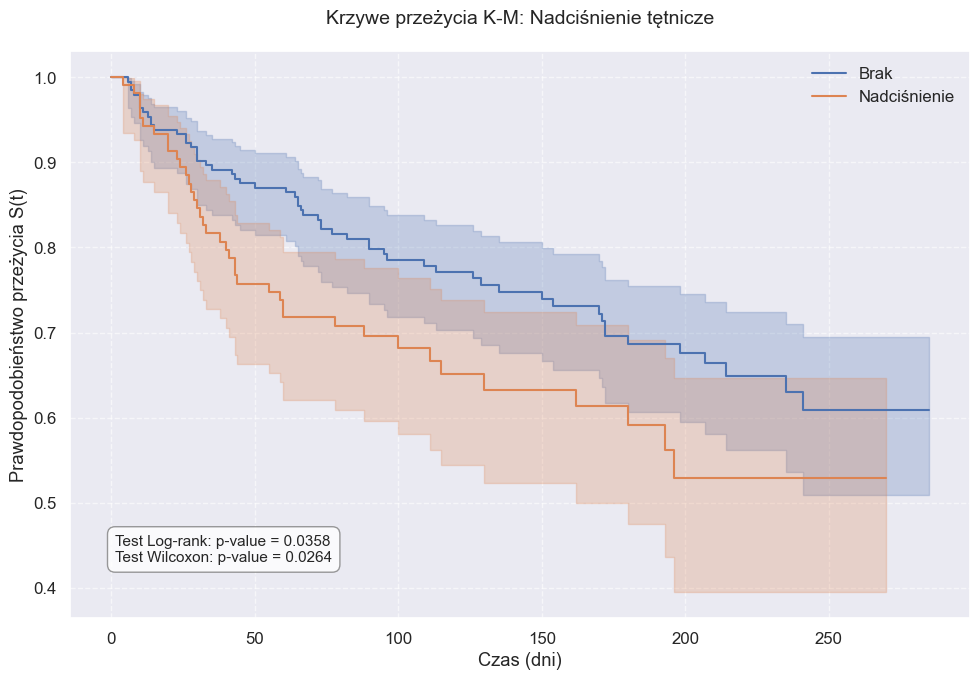


--- WYNIKI DLA ZMIENNEJ: Nadciśnienie tętnicze ---
Test Log-rank: p-value = 0.0358
Test Wilcoxon: p-value = 0.0264
------------------------------------------------------------


In [42]:
analiza_nieparametryczna_grup(df, 'high_blood_pressure', {0: 'Brak', 1: 'Nadciśnienie'}, 'Nadciśnienie tętnicze')

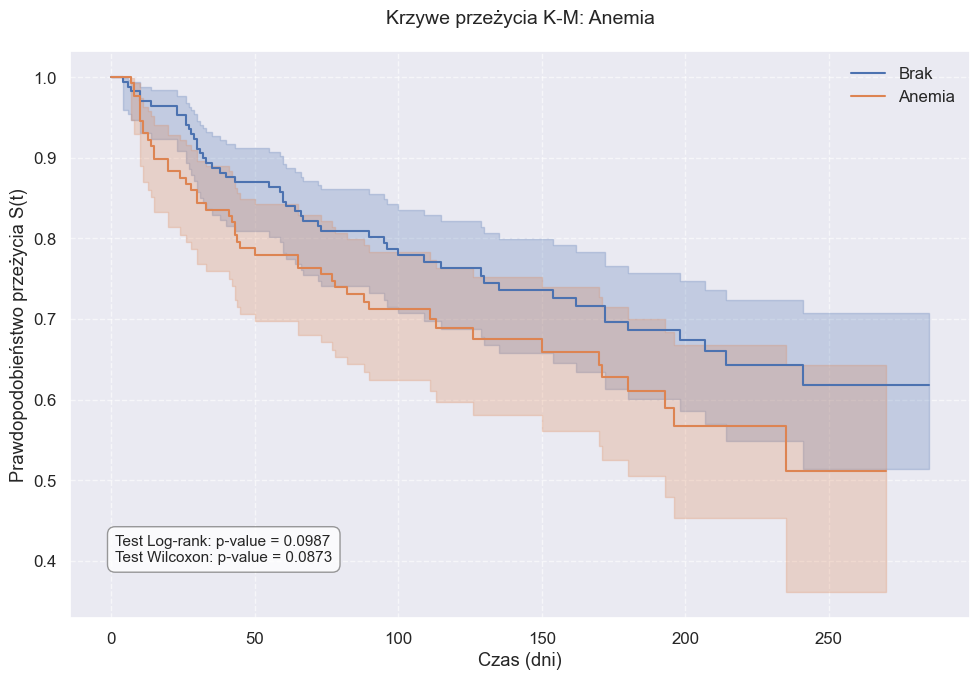


--- WYNIKI DLA ZMIENNEJ: Anemia ---
Test Log-rank: p-value = 0.0987
Test Wilcoxon: p-value = 0.0873
------------------------------------------------------------


In [43]:
analiza_nieparametryczna_grup(df, 'anaemia', {0: 'Brak', 1: 'Anemia'}, 'Anemia')

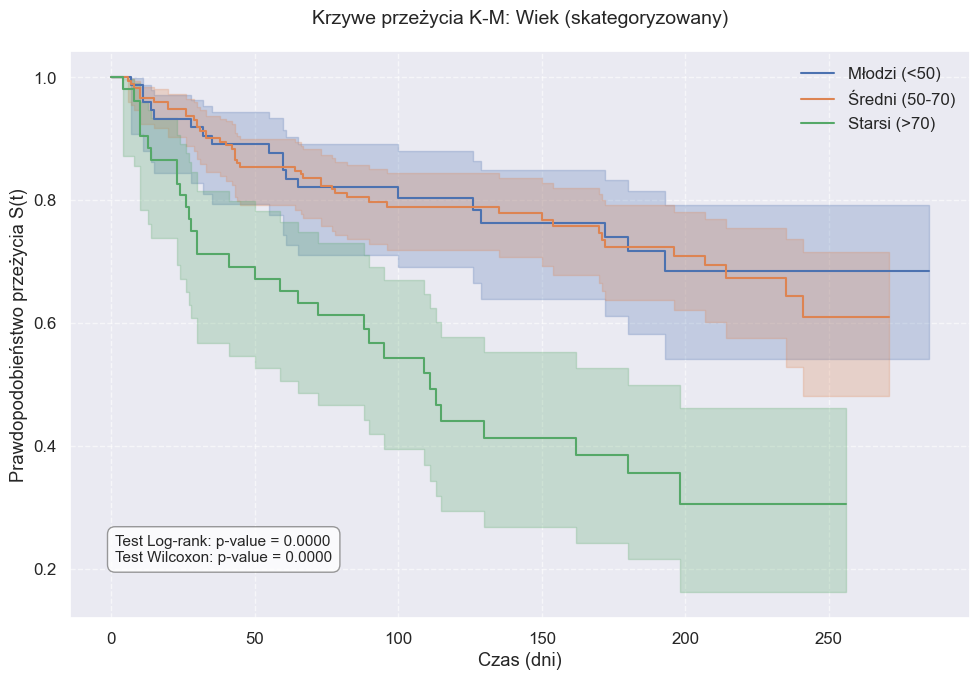


--- WYNIKI DLA ZMIENNEJ: Wiek (skategoryzowany) ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0000

Porównania parami (Log-rank):


,Grupa A,Grupa B,p-value
2,Średni (50-70),Starsi (>70),0.000001
1,Młodzi (<50),Starsi (>70),0.000067
0,Młodzi (<50),Średni (50-70),0.780771


------------------------------------------------------------


In [44]:
df['age_cat'] = pd.cut(df['age'], bins=[0, 50, 70, 100], labels=[0, 1, 2])
analiza_nieparametryczna_grup(df, 'age_cat', {0: 'Młodzi (<50)', 1: 'Średni (50-70)', 2: 'Starsi (>70)'}, 'Wiek (skategoryzowany)')


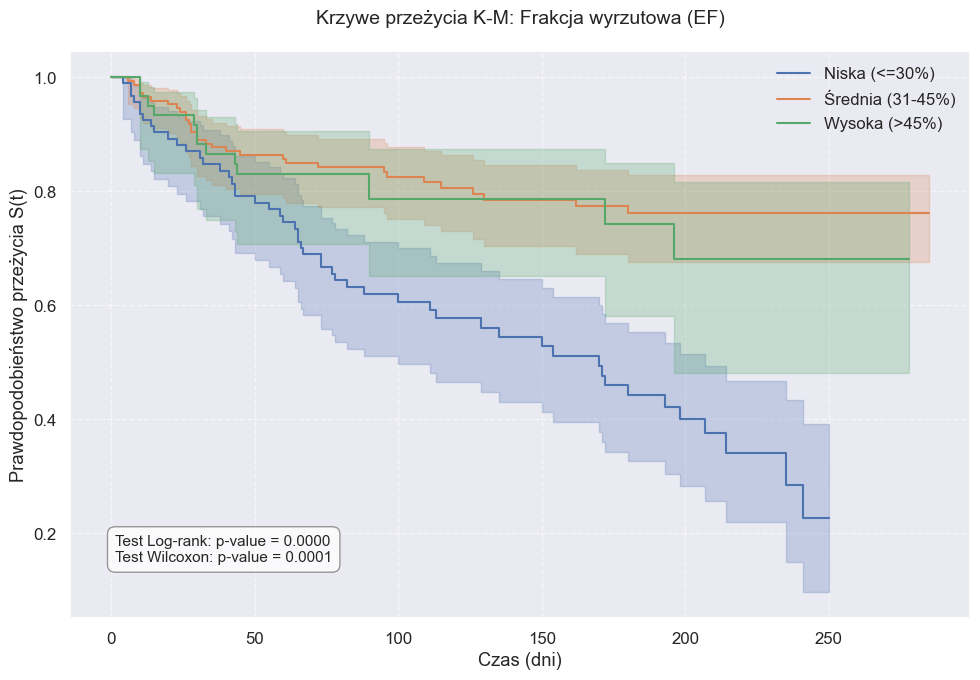


--- WYNIKI DLA ZMIENNEJ: Frakcja wyrzutowa (EF) ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0001

Porównania parami (Log-rank):


,Grupa A,Grupa B,p-value
0,Niska (<=30%),Średnia (31-45%),0.000000
1,Niska (<=30%),Wysoka (>45%),0.002246
2,Średnia (31-45%),Wysoka (>45%),0.549470


------------------------------------------------------------


In [45]:
df['ef_cat'] = pd.cut(df['ejection_fraction'], bins=[0, 30, 45, 100], labels=[0, 1, 2])
analiza_nieparametryczna_grup(df, 'ef_cat', {0: 'Niska (<=30%)', 1: 'Średnia (31-45%)', 2: 'Wysoka (>45%)'}, 'Frakcja wyrzutowa (EF)')

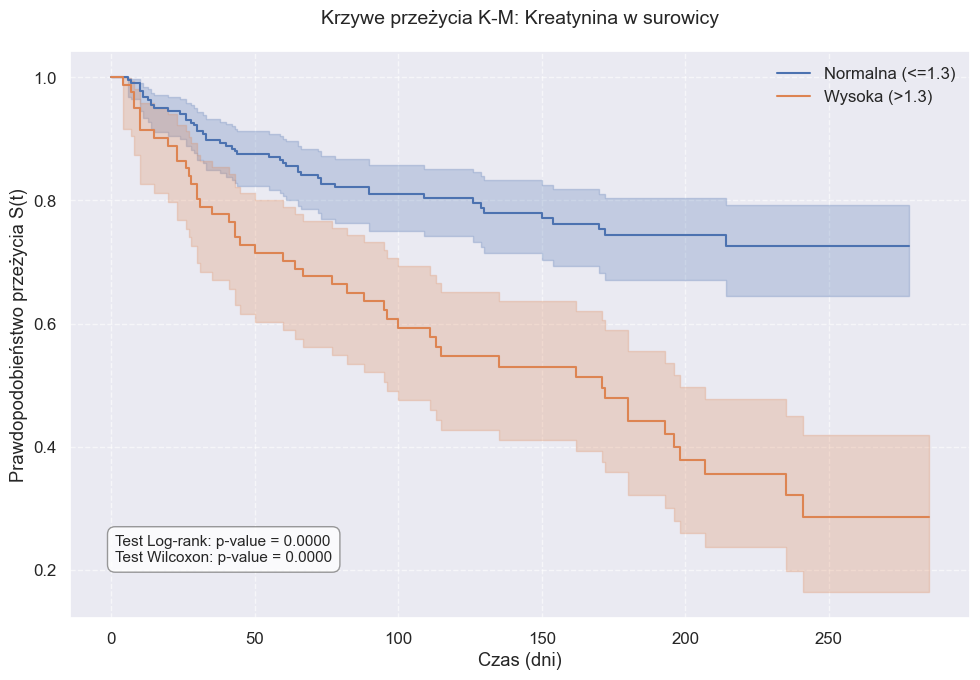


--- WYNIKI DLA ZMIENNEJ: Kreatynina w surowicy ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0000
------------------------------------------------------------


In [46]:
df['creatinine_cat'] = pd.cut(df['serum_creatinine'], bins=[0, 1.3, 10], labels=[0, 1])
analiza_nieparametryczna_grup(df, 'creatinine_cat', {0: 'Normalna (<=1.3)', 1: 'Wysoka (>1.3)'}, 'Kreatynina w surowicy')

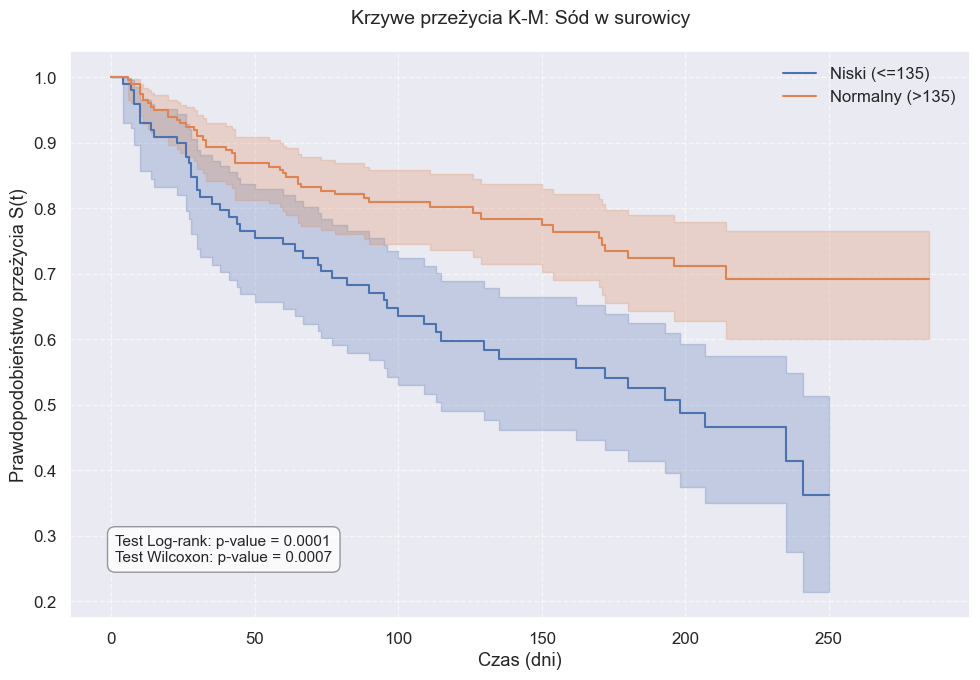


--- WYNIKI DLA ZMIENNEJ: Sód w surowicy ---
Test Log-rank: p-value = 0.0001
Test Wilcoxon: p-value = 0.0007
------------------------------------------------------------


In [47]:
df['sodium_cat'] = pd.cut(df['serum_sodium'], bins=[0, 135, 150], labels=[0, 1])
analiza_nieparametryczna_grup(df, 'sodium_cat', {0: 'Niski (<=135)', 1: 'Normalny (>135)'}, 'Sód w surowicy')